In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [36]:
BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"

TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

for folder in [TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(DATA_DIR)

/Users/naniyalagala003gmail.com/data


In [16]:
!pip install pandas numpy matplotlib seaborn
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [17]:
DATA_PATH = "/Users/naniyalagala003gmail.com/Downloads/geo_all_channels.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 6,240
Columns: 20


In [18]:
df.head()
df.tail()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   6240 non-null   int64  
 1   geo                          6240 non-null   object 
 2   time                         6240 non-null   object 
 3   Channel0_impression          6240 non-null   int64  
 4   Channel1_impression          6240 non-null   int64  
 5   Channel2_impression          6240 non-null   int64  
 6   Channel3_impression          6240 non-null   int64  
 7   Channel4_impression          6240 non-null   int64  
 8   competitor_sales_control     6240 non-null   float64
 9   sentiment_score_control      6240 non-null   float64
 10  Channel0_spend               6240 non-null   float64
 11  Channel1_spend               6240 non-null   float64
 12  Channel2_spend               6240 non-null   float64
 13  Channel3_spend    

In [22]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
geo,6240,40,Geo0,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,6240,156,2021-01-25,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel0_impression,6240.0,NaN,NaN,NaN,885163.536378,819345.148069,0.0,253645.75,679670.5,1324174.25,5192032.0
Channel1_impression,6240.0,NaN,NaN,NaN,520605.540545,620623.143377,0.0,0.0,310652.5,807552.5,4397540.0
Channel2_impression,6240.0,NaN,NaN,NaN,260505.027083,555184.172757,0.0,0.0,0.0,254734.0,5610156.0
Channel3_impression,6240.0,NaN,NaN,NaN,1806810.449359,1304818.09259,0.0,808356.5,1505379.0,2566118.25,7635147.0
Channel4_impression,6240.0,NaN,NaN,NaN,981677.974679,914176.816915,0.0,267594.5,746247.5,1476707.75,6975542.0
competitor_sales_control,6240.0,NaN,NaN,NaN,-0.044412,1.210164,-4.825634,-0.872736,-0.050346,0.743633,3.924682
sentiment_score_control,6240.0,NaN,NaN,NaN,-0.033675,1.175572,-4.230392,-0.808085,-0.036433,0.739391,4.320259
Channel0_spend,6240.0,NaN,NaN,NaN,6490.659147,6008.031135,0.0,1859.914025,4983.8355,9709.803,38071.73


In [23]:
df.columns.tolist()


['geo',
 'time',
 'Channel0_impression',
 'Channel1_impression',
 'Channel2_impression',
 'Channel3_impression',
 'Channel4_impression',
 'competitor_sales_control',
 'sentiment_score_control',
 'Channel0_spend',
 'Channel1_spend',
 'Channel2_spend',
 'Channel3_spend',
 'Channel4_spend',
 'Organic_channel0_impression',
 'Promo',
 'conversions',
 'revenue_per_conversion',
 'population']

In [26]:
df["time"] = pd.to_datetime(df["time"])

print(df["time"].min())
print(df["time"].max())
df = df.sort_values(["geo", "time"]).reset_index(drop=True)

2021-01-25 00:00:00
2024-01-15 00:00:00


In [27]:
print("Number of observations:", len(df))
print("Number of geographies:", df["geo"].nunique())
print("Number of weeks:", df["time"].nunique())

Number of observations: 6240
Number of geographies: 40
Number of weeks: 156


In [28]:
print("\nGeographies:")
print(df["geo"].unique())


Geographies:
['Geo0' 'Geo1' 'Geo10' 'Geo11' 'Geo12' 'Geo13' 'Geo14' 'Geo15' 'Geo16'
 'Geo17' 'Geo18' 'Geo19' 'Geo2' 'Geo20' 'Geo21' 'Geo22' 'Geo23' 'Geo24'
 'Geo25' 'Geo26' 'Geo27' 'Geo28' 'Geo29' 'Geo3' 'Geo30' 'Geo31' 'Geo32'
 'Geo33' 'Geo34' 'Geo35' 'Geo36' 'Geo37' 'Geo38' 'Geo39' 'Geo4' 'Geo5'
 'Geo6' 'Geo7' 'Geo8' 'Geo9']


In [29]:
panel_check = (
    df.groupby("geo")["time"]
      .nunique()
)

print(panel_check.value_counts())

time
156    40
Name: count, dtype: int64


In [30]:
duplicates = df.duplicated(
    subset=["geo", "time"]
).sum()

print("Duplicate geo-time observations:", duplicates)

Duplicate geo-time observations: 0


In [34]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing
missing_pct = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_pct

geo                            0.0
Channel1_spend                 0.0
revenue_per_conversion         0.0
conversions                    0.0
Promo                          0.0
Organic_channel0_impression    0.0
Channel4_spend                 0.0
Channel3_spend                 0.0
Channel2_spend                 0.0
Channel0_spend                 0.0
time                           0.0
sentiment_score_control        0.0
competitor_sales_control       0.0
Channel4_impression            0.0
Channel3_impression            0.0
Channel2_impression            0.0
Channel1_impression            0.0
Channel0_impression            0.0
population                     0.0
dtype: float64

In [37]:
missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

missing_table.to_csv(
    TABLE_DIR / "missing_value_report.csv"
)

In [39]:
#variable groups
spend_cols = [
    "Channel0_spend",
    "Channel1_spend",
    "Channel2_spend",
    "Channel3_spend",
    "Channel4_spend"
]

impression_cols = [
    "Channel0_impression",
    "Channel1_impression",
    "Channel2_impression",
    "Channel3_impression",
    "Channel4_impression"
]

control_cols = [
    "competitor_sales_control",
    "sentiment_score_control",
    "Promo",
    "population"
]

organic_cols = [
    "Organic_channel0_impression"
]

target_col = "conversions"
print("Spend:", spend_cols)
print("Impressions:", impression_cols)
print("Controls:", control_cols)
print("Target:", target_col)

Spend: ['Channel0_spend', 'Channel1_spend', 'Channel2_spend', 'Channel3_spend', 'Channel4_spend']
Impressions: ['Channel0_impression', 'Channel1_impression', 'Channel2_impression', 'Channel3_impression', 'Channel4_impression']
Controls: ['competitor_sales_control', 'sentiment_score_control', 'Promo', 'population']
Target: conversions


In [40]:
# Create Data Dictionary
data_dictionary = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum().values,
    "unique_values": df.nunique().values
})

data_dictionary

,variable,dtype,missing,unique_values
geo,geo,object,0,40
time,time,datetime64[ns],0,156
Channel0_impression,Channel0_impression,int64,0,5483
Channel1_impression,Channel1_impression,int64,0,4491
Channel2_impression,Channel2_impression,int64,0,2226
Channel3_impression,Channel3_impression,int64,0,6069
Channel4_impression,Channel4_impression,int64,0,5416
competitor_sales_control,competitor_sales_control,float64,0,6240
sentiment_score_control,sentiment_score_control,float64,0,6239
Channel0_spend,Channel0_spend,float64,0,5483


In [42]:
data_dictionary.to_csv(
    TABLE_DIR / "data_dictionary.csv",
    index=False
)

In [43]:
#  Marketing spend analysis
spend_summary = df[spend_cols].describe().T

spend_summary

,count,mean,std,min,25%,50%,75%,max
Channel0_spend,6240.0,6490.659147,6008.031135,0.0,1859.914025,4983.83550,9709.803000,38071.730
Channel1_spend,6240.0,5019.278558,5983.571424,0.0,0.000000,2995.07265,7785.800675,42397.700
Channel2_spend,6240.0,1935.793164,4125.531614,0.0,0.000000,0.00000,1892.909150,41688.645
Channel3_spend,6240.0,14080.185617,10168.239254,0.0,6299.393250,11731.17850,19997.351500,59499.484
Channel4_spend,6240.0,7649.147993,7123.184932,0.0,2085.072625,5814.69460,11506.376500,54352.810


In [44]:
spend_summary["zero_count"] = (
    df[spend_cols] == 0
).sum()

spend_summary["zero_percent"] = (
    (df[spend_cols] == 0)
    .mean()
    .mul(100)
)

spend_summary

,count,mean,std,min,25%,50%,75%,max,zero_count,zero_percent
Channel0_spend,6240.0,6490.659147,6008.031135,0.0,1859.914025,4983.83550,9709.803000,38071.730,755,12.099359
Channel1_spend,6240.0,5019.278558,5983.571424,0.0,0.000000,2995.07265,7785.800675,42397.700,1742,27.916667
Channel2_spend,6240.0,1935.793164,4125.531614,0.0,0.000000,0.00000,1892.909150,41688.645,4010,64.262821
Channel3_spend,6240.0,14080.185617,10168.239254,0.0,6299.393250,11731.17850,19997.351500,59499.484,169,2.708333
Channel4_spend,6240.0,7649.147993,7123.184932,0.0,2085.072625,5814.69460,11506.376500,54352.810,820,13.141026


In [47]:
# Total market EXpenditure
total_spend = df[spend_cols].sum()

total_spend
spend_share = (
    total_spend / total_spend.sum() * 100
).sort_values(ascending=False)

spend_share
spend_table = pd.DataFrame({
    "total_spend": total_spend,
    "share_percent": spend_share
})

spend_table

,total_spend,share_percent
Channel0_spend,4.050171e+07,18.452444
Channel1_spend,3.132030e+07,14.269422
Channel2_spend,1.207935e+07,5.503311
Channel3_spend,8.786036e+07,40.028884
Channel4_spend,4.773068e+07,21.745939


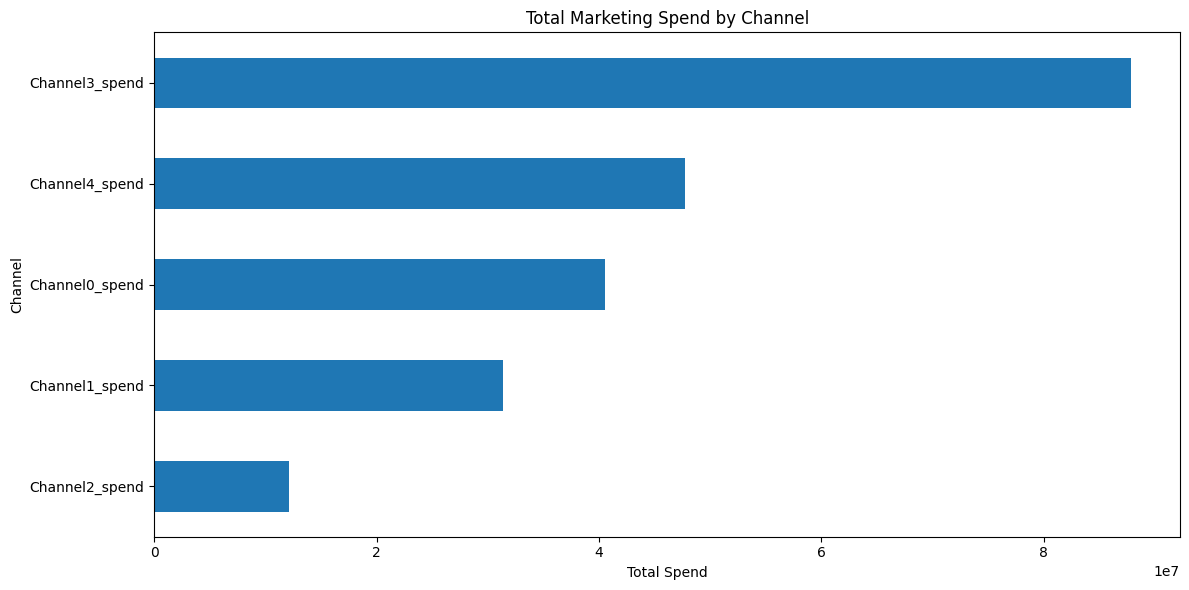

In [48]:
#Marketing spend visualization
plt.figure(figsize=(12, 6))

total_spend.sort_values().plot(
    kind="barh"
)

plt.title("Total Marketing Spend by Channel")
plt.xlabel("Total Spend")
plt.ylabel("Channel")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "total_spend_by_channel.png",
    dpi=300
)

plt.show()

In [49]:
# Weekly marketing expenditure
weekly_spend = (
    df.groupby("time")[spend_cols]
      .sum()
)

weekly_spend.head()

,Channel0_spend,Channel1_spend,Channel2_spend,Channel3_spend,Channel4_spend
time,,,,,
2021-01-25,325137.56830,101595.404270,48315.04518,520082.5242,413173.984050
2021-02-01,347511.96809,297505.263890,59197.12148,615634.5403,214996.093200
2021-02-08,212357.01945,223143.885196,34462.68770,533361.9165,156285.964472
2021-02-15,279567.52290,102843.758830,22513.00335,550183.0380,290222.395240
2021-02-22,343837.20920,172828.342330,77926.91530,637786.8024,438369.280950


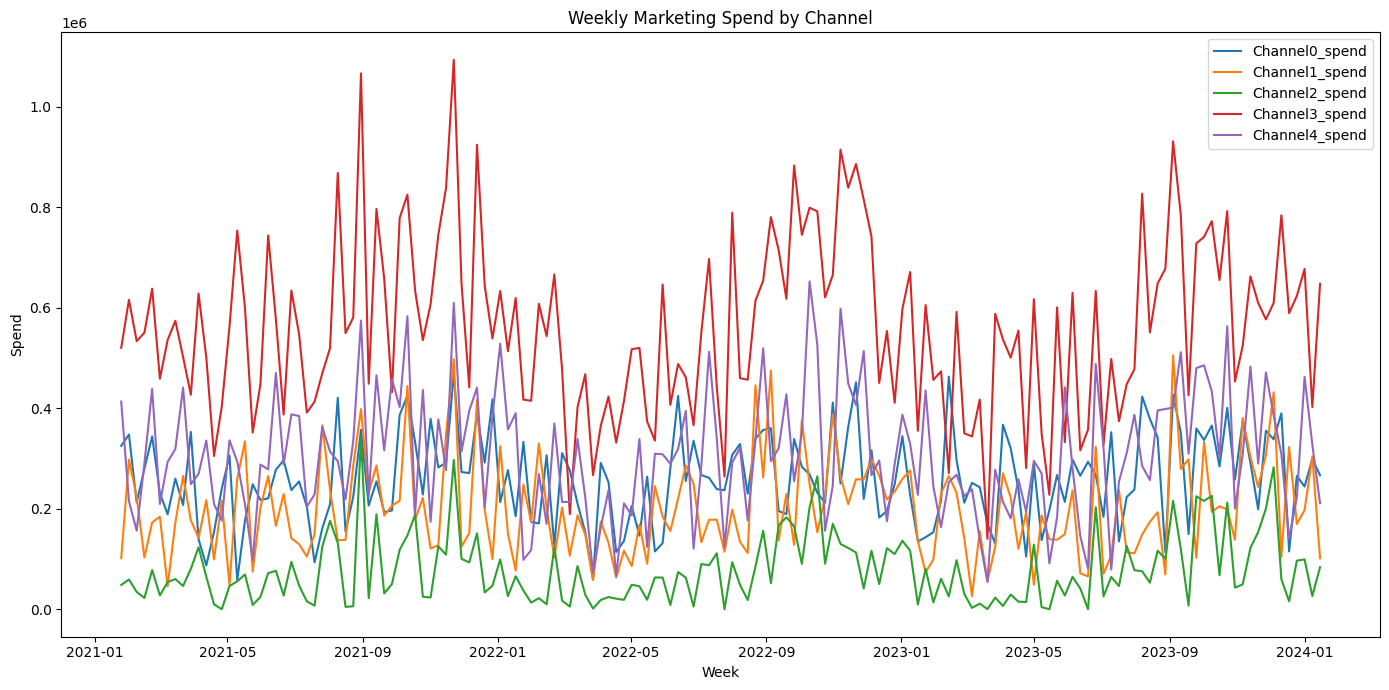

In [50]:
plt.figure(figsize=(14, 7))

for col in spend_cols:
    plt.plot(
        weekly_spend.index,
        weekly_spend[col],
        label=col
    )

plt.title("Weekly Marketing Spend by Channel")
plt.xlabel("Week")
plt.ylabel("Spend")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "weekly_marketing_spend.png",
    dpi=300
)

plt.show()

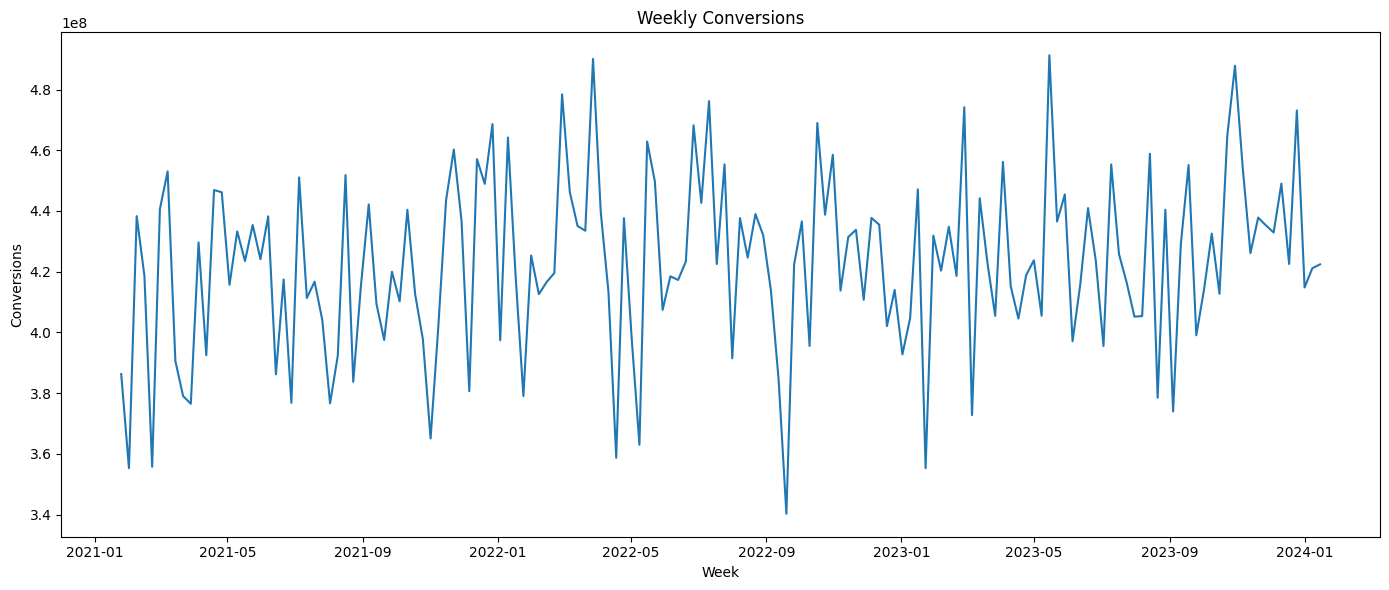

In [53]:
#Weekly conversions
weekly_conversions = (
    df.groupby("time")["conversions"]
      .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    weekly_conversions.index,
    weekly_conversions.values
)

plt.title("Weekly Conversions")
plt.xlabel("Week")
plt.ylabel("Conversions")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "weekly_conversions.png",
    dpi=300
)

plt.show()

In [55]:
#Revenue
df["revenue"] = (
    df["conversions"]
    * df["revenue_per_conversion"]
)
df["revenue"].describe()

count      6240.000000
mean     211330.038099
std      121605.908396
min        9742.282233
25%      114323.174381
50%      193995.582649
75%      287918.213647
max      739823.338940
Name: revenue, dtype: float64

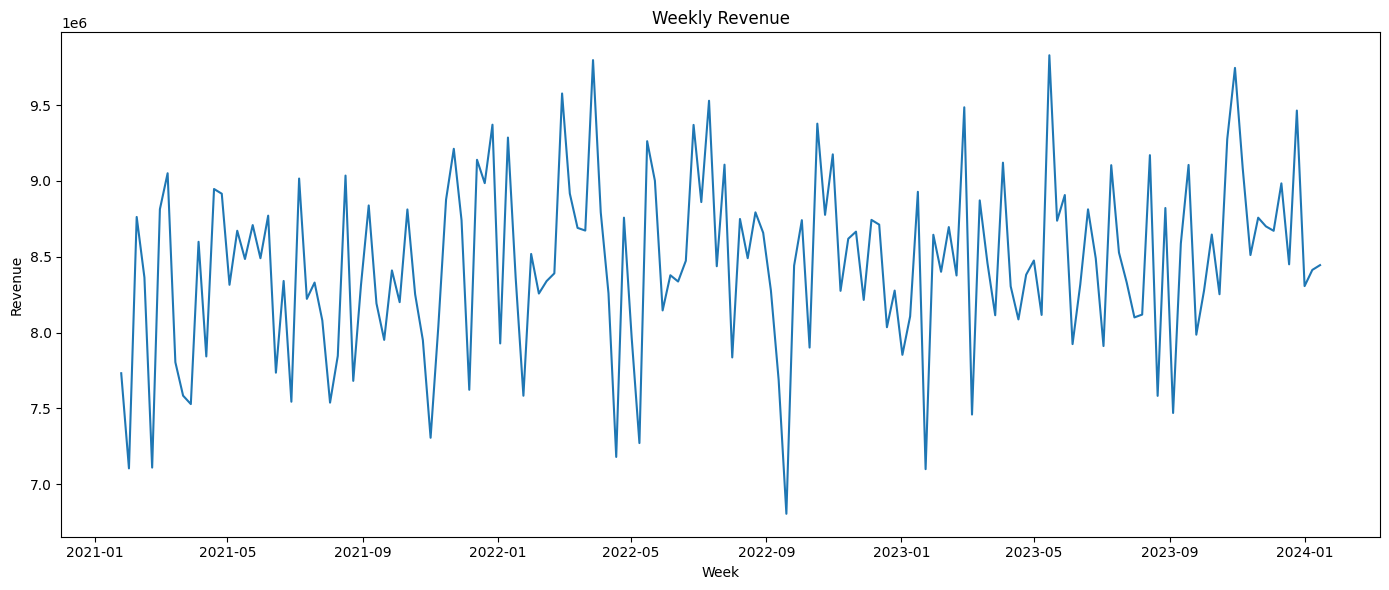

In [58]:
#Weekly Revenue
weekly_revenue = (
    df.groupby("time")["revenue"]
      .sum()
)
plt.figure(figsize=(14, 6))

plt.plot(
    weekly_revenue.index,
    weekly_revenue.values
)

plt.title("Weekly Revenue")
plt.xlabel("Week")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "weekly_revenue.png",
    dpi=300
)

plt.show()

In [62]:
#Geography analysis
geo_summary = (
    df.groupby("geo")
      .agg(
          conversions=("conversions", "sum"),
          revenue=("revenue", "sum"),
          population=("population", "mean")
      )
      .sort_values("revenue", ascending=False)
)

geo_summary.head(10)


,conversions,revenue,population
geo,,,
Geo36,3.290565e+09,6.581648e+07,969886.50
Geo39,3.222847e+09,6.448245e+07,798939.10
Geo10,3.093954e+09,6.191079e+07,994048.94
Geo23,2.836450e+09,5.673184e+07,981570.90
Geo31,2.684670e+09,5.367754e+07,873369.70
Geo7,2.578130e+09,5.153221e+07,733989.56
Geo2,2.468820e+09,4.937024e+07,892369.50
Geo25,2.437115e+09,4.872741e+07,779181.90
Geo17,2.201843e+09,4.408524e+07,777539.94


In [63]:
# Spend by Geography
geo_spend = (
    df.groupby("geo")[spend_cols]
      .sum()
)

geo_spend.head()

,Channel0_spend,Channel1_spend,Channel2_spend,Channel3_spend,Channel4_spend
geo,,,,,
Geo0,2.467536e+05,2.157888e+05,74610.828148,5.460870e+05,2.807748e+05
Geo1,3.865346e+05,2.911878e+05,123895.855714,8.020486e+05,4.524910e+05
Geo10,1.722232e+06,1.331248e+06,478083.500860,3.982157e+06,2.166376e+06
Geo11,1.260501e+06,9.178455e+05,380417.417384,2.746338e+06,1.461877e+06
Geo12,9.921830e+05,8.177287e+05,316180.193305,2.147704e+06,1.244653e+06


In [64]:
geo_spend["total_spend"] = geo_spend.sum(axis=1)

geo_spend.sort_values(
    "total_spend",
    ascending=False
).head(10)

,Channel0_spend,Channel1_spend,Channel2_spend,Channel3_spend,Channel4_spend,total_spend
geo,,,,,,
Geo23,1.836282e+06,1.470649e+06,591659.585900,3.991148e+06,2.047431e+06,9.937170e+06
Geo36,1.854902e+06,1.417560e+06,601119.031330,3.799767e+06,2.087676e+06,9.761024e+06
Geo10,1.722232e+06,1.331248e+06,478083.500860,3.982157e+06,2.166376e+06,9.680096e+06
Geo2,1.694490e+06,1.318968e+06,583637.296240,3.838470e+06,1.997237e+06,9.432803e+06
Geo31,1.733547e+06,1.342863e+06,435806.661720,3.293982e+06,1.861796e+06,8.667995e+06
Geo17,1.572221e+06,1.227276e+06,374765.033620,3.123829e+06,1.723958e+06,8.022049e+06
Geo14,1.338354e+06,1.129250e+06,517482.308584,3.260596e+06,1.768387e+06,8.014070e+06
Geo25,1.535507e+06,1.196871e+06,396635.370186,3.155478e+06,1.705967e+06,7.990459e+06
Geo35,1.400227e+06,9.661306e+05,502650.508740,3.211879e+06,1.735845e+06,7.816732e+06


In [66]:
# Coversion for 1000 people(efficiency)
geo_summary["conversions_per_1000"] = (
    geo_summary["conversions"]
    / geo_summary["population"]
    * 1000
)

geo_summary.sort_values(
    "conversions_per_1000",
    ascending=False
).head(10)

,conversions,revenue,population,conversions_per_1000
geo,,,,
Geo39,3.222847e+09,6.448245e+07,798939.10,4.033908e+06
Geo9,1.893569e+09,3.788314e+07,513695.22,3.686171e+06
Geo7,2.578130e+09,5.153221e+07,733989.56,3.512489e+06
Geo36,3.290565e+09,6.581648e+07,969886.50,3.392732e+06
Geo29,1.422899e+09,2.845106e+07,428704.50,3.319068e+06
Geo4,1.114963e+09,2.228475e+07,337852.20,3.300149e+06
Geo22,1.335522e+09,2.669168e+07,411040.88,3.249122e+06
Geo30,8.741693e+08,1.748423e+07,270937.94,3.226456e+06
Geo37,1.041247e+09,2.082628e+07,327985.06,3.174678e+06


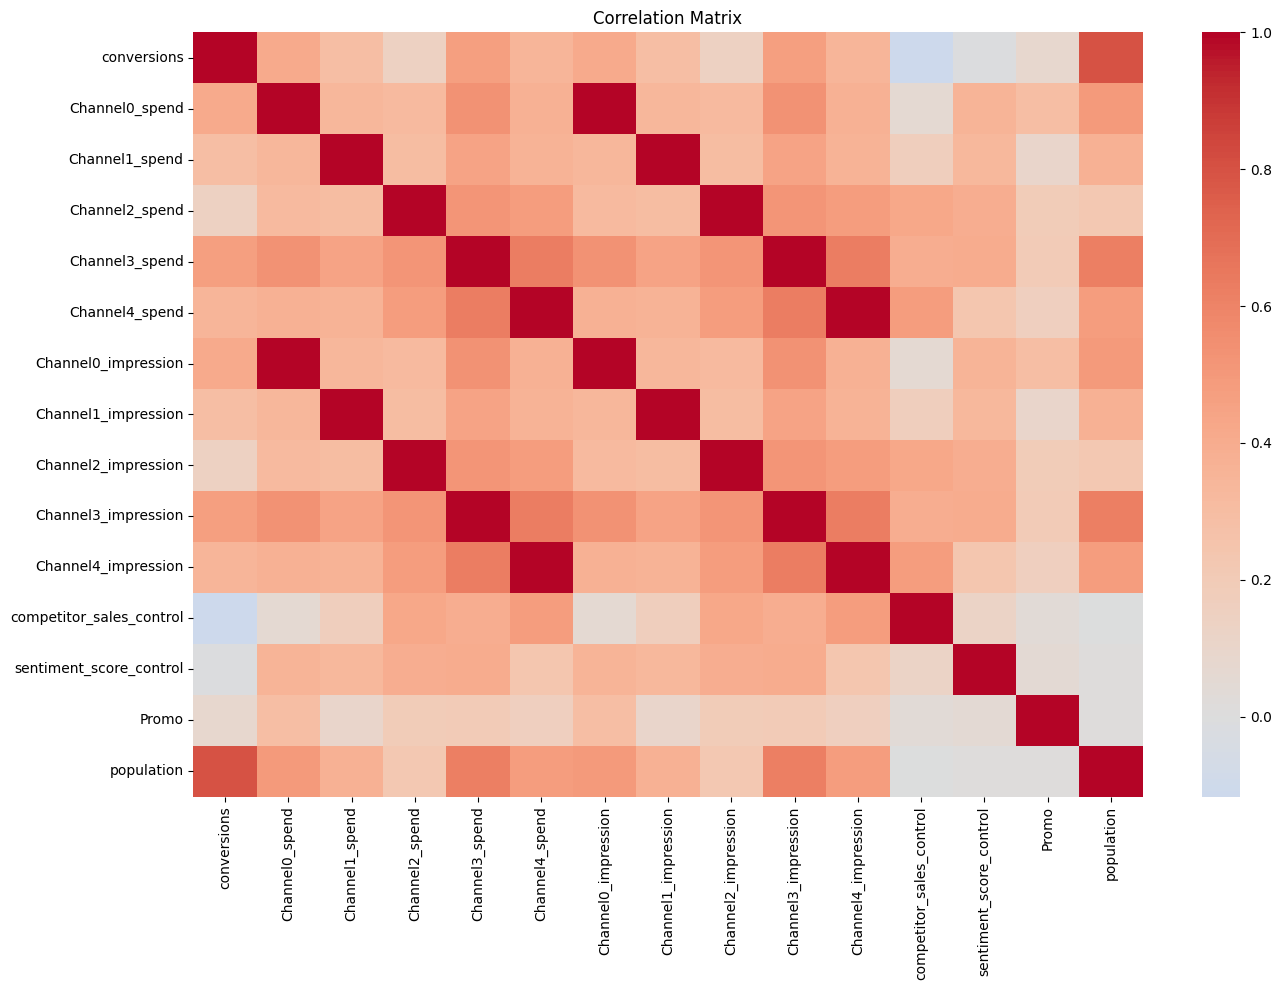

In [70]:
# Channel Crrelation
correlation_cols = (
    [target_col]
    + spend_cols
    + impression_cols
    + control_cols
)

corr = df[correlation_cols].corr()
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "correlation_matrix.png",
    dpi=300
)

plt.show()

In [72]:
# Bseline Regression  - First aggregate to national weekly level.
national = (
    df.groupby("time")
      .agg(
          conversions=("conversions", "sum"),
          revenue=("revenue", "sum"),
          competitor_sales_control=("competitor_sales_control", "mean"),
          sentiment_score_control=("sentiment_score_control", "mean"),
          Promo=("Promo", "mean")
      )
      .reset_index()
)

In [74]:
# Add weeekly spend 
weekly_spend_reset = (
    df.groupby("time")[spend_cols]
      .sum()
      .reset_index()
)

national = national.merge(
    weekly_spend_reset,
    on="time",
    how="left"
)

In [93]:
# OLS model 
#%pip install statsmodels

import statsmodels.api as sm

X = national[
    spend_cols
    + [
        "competitor_sales_control",
        "sentiment_score_control",
        "Promo"
    ]
]

y = national["conversions"]

X = sm.add_constant(X)

ols_model = sm.OLS(
    y,
    X
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            conversions   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     7.659
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.52e-08
Time:                        19:58:48   Log-Likelihood:                -2875.3
No. Observations:                 156   AIC:                             5769.
Df Residuals:                     147   BIC:                             5796.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [103]:
# SAVE THE MODEL 
with open(
    TABLE_DIR / "ols_summary.txt",
    "w"
) as f:
    f.write(ols_model.summary().as_text())

In [105]:
#Ridge regression

# Marketing channels can be correlated, so let's also create a Ridge benchmark.
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

X = national[
    spend_cols
    + [
        "competitor_sales_control",
        "sentiment_score_control",
        "Promo"
    ]
]

y = national["conversions"]

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X, y)

ridge_predictions = ridge_model.predict(X)

/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [106]:

#Baseline model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y,
    ridge_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y,
        ridge_predictions
    )
)

r2 = r2_score(
    y,
    ridge_predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 19354977.21838865
RMSE: 24463820.733469766
R²: 0.2941432628038385


In [107]:
print(df.shape)
print(df.dtypes)
print(df.describe().T)
print(df.isna().sum())
print(df["geo"].nunique())
print(df["time"].min())
print(df["time"].max())

(6240, 20)
geo                                    object
time                           datetime64[ns]
Channel0_impression                     int64
Channel1_impression                     int64
Channel2_impression                     int64
Channel3_impression                     int64
Channel4_impression                     int64
competitor_sales_control              float64
sentiment_score_control               float64
Channel0_spend                        float64
Channel1_spend                        float64
Channel2_spend                        float64
Channel3_spend                        float64
Channel4_spend                        float64
Organic_channel0_impression             int64
Promo                                 float64
conversions                           float64
revenue_per_conversion                float64
population                            float64
revenue                               float64
dtype: object
                              count                    